In [1]:
import os
from PIL import Image

# 你的原始数据源路径
source_dir = '/Users/alpha/Documents/Learning/Coding/Winter Quarter /Bayes ML/archive/ut-zap50k-images/ut-zap50k-images/Shoes/Sneakers and Athletic Shoes'

# 我们将处理好的数据保存在当前 ipynb 目录下的新文件夹中
target_dir = './processed_sneakers_64x64'

def process_and_save_images(src, dst):
    # 如果目标文件夹不存在，则创建
    if not os.path.exists(dst):
        os.makedirs(dst)

    valid_extensions = ('.jpg', '.jpeg', '.png')
    processed_count = 0

    print("开始预处理并保存图片到本地，这可能需要一两分钟...")

    # 使用 os.walk 遍历所有子文件夹（品牌目录）
    for root, dirs, files in os.walk(src):
        for file in files:
            if file.lower().endswith(valid_extensions):
                # 获取原始文件完整路径
                file_path = os.path.join(root, file)
                
                # 构建目标子文件夹路径（保留原有的品牌分类结构）
                relative_path = os.path.relpath(root, src)
                target_subfolder = os.path.join(dst, relative_path)
                if not os.path.exists(target_subfolder):
                    os.makedirs(target_subfolder)
                    
                target_file_path = os.path.join(target_subfolder, file)

                try:
                    # 1. 打开原图
                    img = Image.open(file_path).convert('RGB')
                    
                    # 2. 计算居中 Padding，将其补成白底正方形
                    w, h = img.size
                    max_wh = max(w, h)
                    
                    # 创建一张纯白 (255, 255, 255) 的正方形底图
                    new_img = Image.new('RGB', (max_wh, max_wh), (255, 255, 255))
                    
                    # 将原图粘贴到正中心
                    offset = ((max_wh - w) // 2, (max_wh - h) // 2)
                    new_img.paste(img, offset)
                    
                    # 3. 缩放到 64x64 (使用 LANCZOS 算法保证缩放质量)
                    final_img = new_img.resize((64, 64), Image.Resampling.LANCZOS)
                    
                    # 4. 保存到本地
                    final_img.save(target_file_path)
                    processed_count += 1
                    
                    # 每处理 2000 张打印一次进度
                    if processed_count % 2000 == 0:
                        print(f"已处理并保存 {processed_count} 张图片...")
                        
                except Exception as e:
                    print(f"处理文件 {file_path} 时出错: {e}")

    print(f"✅ 预处理完成！共成功保存 {processed_count} 张 64x64 的图片至 {dst}")

# 执行预处理函数
process_and_save_images(source_dir, target_dir)

开始预处理并保存图片到本地，这可能需要一两分钟...
已处理并保存 2000 张图片...
已处理并保存 4000 张图片...
已处理并保存 6000 张图片...
已处理并保存 8000 张图片...
已处理并保存 10000 张图片...
已处理并保存 12000 张图片...
✅ 预处理完成！共成功保存 12856 张 64x64 的图片至 ./processed_sneakers_64x64


In [4]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ==========================================
# 2.1 快速加载我们刚处理好的本地数据
# ==========================================
processed_data_dir = './processed_sneakers_64x64' # 刚刚保存的文件夹路径

# 这里只需要最基础的 Transform，因为图片已经是 64x64 的白底正方形了
fast_transform = transforms.Compose([
    transforms.ToTensor() # 转换为 Tensor 并将像素归一化到 [0, 1]
])

# 加载数据 (因为我们之前保留了子文件夹结构，所以 ImageFolder 依然适用)
dataset = datasets.ImageFolder(root=processed_data_dir, transform=fast_transform)

# 设置 DataLoader (batch_size 设为 64 或 128 都可以，M4 内存管够)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)
print(f"📦 DataLoader 准备完毕！每个 Epoch 有 {len(dataloader)} 个 Batch。")

# ==========================================
# 2.2 定义 β-VAE 模型
# ==========================================
class BetaVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super(BetaVAE, self).__init__()
        self.latent_dim = latent_dim
        
        # --- Encoder (编码器) ---
        # 输入: [Batch, 3, 64, 64]
        self.encoder = nn.Sequential(
            # Conv1: 64x64 -> 32x32
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            # Conv2: 32x32 -> 16x16
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            # Conv3: 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            # Conv4: 8x8 -> 4x4
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2)
        )
        
        # 展平后维度: 256 * 4 * 4 = 4096
        # 输出均值 μ (mu) 和 对数方差 log(σ^2) (log_var)
        self.fc_mu = nn.Linear(4096, latent_dim)
        self.fc_log_var = nn.Linear(4096, latent_dim)
        
        # --- Decoder (解码器) ---
        # 将隐变量恢复回 4096 维
        self.fc_decode = nn.Linear(latent_dim, 4096)
        
        # 反卷积上采样网络
        self.decoder = nn.Sequential(
            # ConvT1: 4x4 -> 8x8
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            # ConvT2: 8x8 -> 16x16
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            # ConvT3: 16x16 -> 32x32
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            # ConvT4: 32x32 -> 64x64
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            # 最后用 Sigmoid 将像素值压缩回 [0, 1] 之间，配合输入
            nn.Sigmoid()
        )

    # 核心：重参数化技巧 (Reparameterization Trick)
    def reparameterize(self, mu, log_var):
        # 计算标准差 sigma
        std = torch.exp(0.5 * log_var)
        # 从标准正态分布 N(0, 1) 中采样 epsilon
        eps = torch.randn_like(std)
        # 组合得到隐变量 z
        return mu + eps * std

    def forward(self, x):
        # 1. 编码提取特征图
        x_encoded = self.encoder(x)
        # 2. 展平
        x_flat = torch.flatten(x_encoded, start_dim=1)
        # 3. 计算 mu 和 log_var
        mu = self.fc_mu(x_flat)
        log_var = self.fc_log_var(x_flat)
        # 4. 重参数化采样得到 z
        z = self.reparameterize(mu, log_var)
        # 5. 解码准备，先映射回高维再 reshape 回特征图形状
        z_decoded = self.fc_decode(z)
        z_reshaped = z_decoded.view(-1, 256, 4, 4)
        # 6. 反卷积重构图像
        reconstruction = self.decoder(z_reshaped)
        
        return reconstruction, mu, log_var

# 测试一下模型是否能跑通
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"🚀 当前使用的计算设备: {device}")

# 初始化模型，我们先尝试 16 维的隐空间（维度越小，信息瓶颈越强，越有利于 β-VAE 解耦）
model = BetaVAE(latent_dim=16).to(device)

# 制造一个假输入测试前向传播
dummy_input = torch.randn(8, 3, 64, 64).to(device) # Batch size 8
recon, mu, log_var = model(dummy_input)

print(f"✅ 模型前向传播测试成功！")
print(f"输出图像形状: {recon.shape} (预期 [8, 3, 64, 64])")
print(f"μ 形状: {mu.shape} (预期 [8, 16])")

📦 DataLoader 准备完毕！每个 Epoch 有 101 个 Batch。
🚀 当前使用的计算设备: mps
✅ 模型前向传播测试成功！
输出图像形状: torch.Size([8, 3, 64, 64]) (预期 [8, 3, 64, 64])
μ 形状: torch.Size([8, 16]) (预期 [8, 16])


🔥 开始训练！使用的 β 值为: 4.0
Epoch [1/20] | Average Loss: 621.6412
Epoch [5/20] | Average Loss: 256.3898
Epoch [10/20] | Average Loss: 241.8993
Epoch [15/20] | Average Loss: 237.9141
Epoch [20/20] | Average Loss: 234.8448
✅ 训练完成！


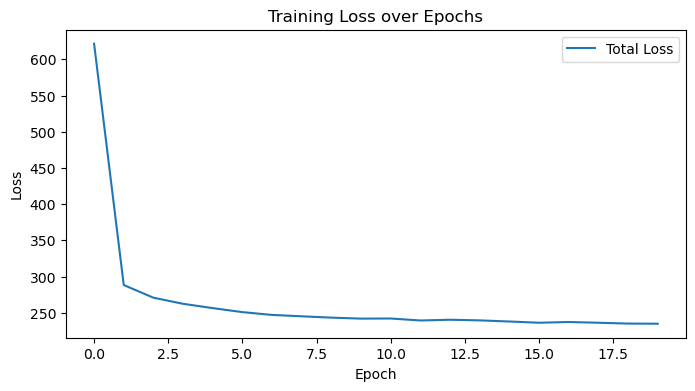

In [5]:
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# ==========================================
# 3.1 定义 β-VAE 损失函数
# ==========================================
def beta_vae_loss(recon_x, x, mu, log_var, beta=4.0):
    # 1. 重构损失 (Reconstruction Loss): 使用 MSE，将整张图片的误差求和
    # 注意：因为我们在 Decoder 最后加了 Sigmoid，预测值在 [0, 1]，真实图片 x 也在 [0, 1]
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # 2. KL 散度 (KL Divergence): 两个高斯分布之间的解析解公式
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    # 3. 总损失
    total_loss = recon_loss + beta * kl_loss
    
    return total_loss, recon_loss, kl_loss

# ==========================================
# 3.2 初始化优化器和训练参数
# ==========================================
# 学习率设为 1e-3 比较标准
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 设定 β 值 (这是你后续可以调参的重点，我们先用 4.0 试试水)
BETA = 4.0
EPOCHS = 20  # M4 跑 20 个 epoch 会非常快

print(f"🔥 开始训练！使用的 β 值为: {BETA}")

# ==========================================
# 3.3 开始训练循环
# ==========================================
# 记录 loss 的列表，方便等下画图
train_loss_history = []

for epoch in range(EPOCHS):
    model.train() # 设置为训练模式
    train_loss = 0.0
    
    for batch_idx, (data, _) in enumerate(dataloader):
        # ⚠️ 必须把数据推到 M4 的 GPU 上
        data = data.to(device)
        
        # 1. 梯度清零
        optimizer.zero_grad()
        
        # 2. 前向传播
        recon_batch, mu, log_var = model(data)
        
        # 3. 计算损失
        loss, bce, kld = beta_vae_loss(recon_batch, data, mu, log_var, beta=BETA)
        
        # 4. 反向传播
        loss.backward()
        
        # 5. 更新参数
        optimizer.step()
        
        train_loss += loss.item()
    
    # 计算当前 Epoch 的平均 Loss
    avg_loss = train_loss / len(dataloader.dataset)
    train_loss_history.append(avg_loss)
    
    # 每 5 个 Epoch 打印一次状态
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Average Loss: {avg_loss:.4f}")

print("✅ 训练完成！")

# 画一下 Loss 曲线看看是否收敛
plt.figure(figsize=(8, 4))
plt.plot(train_loss_history, label='Total Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

🎨 正在生成特征解耦矩阵，这可能需要几秒钟...


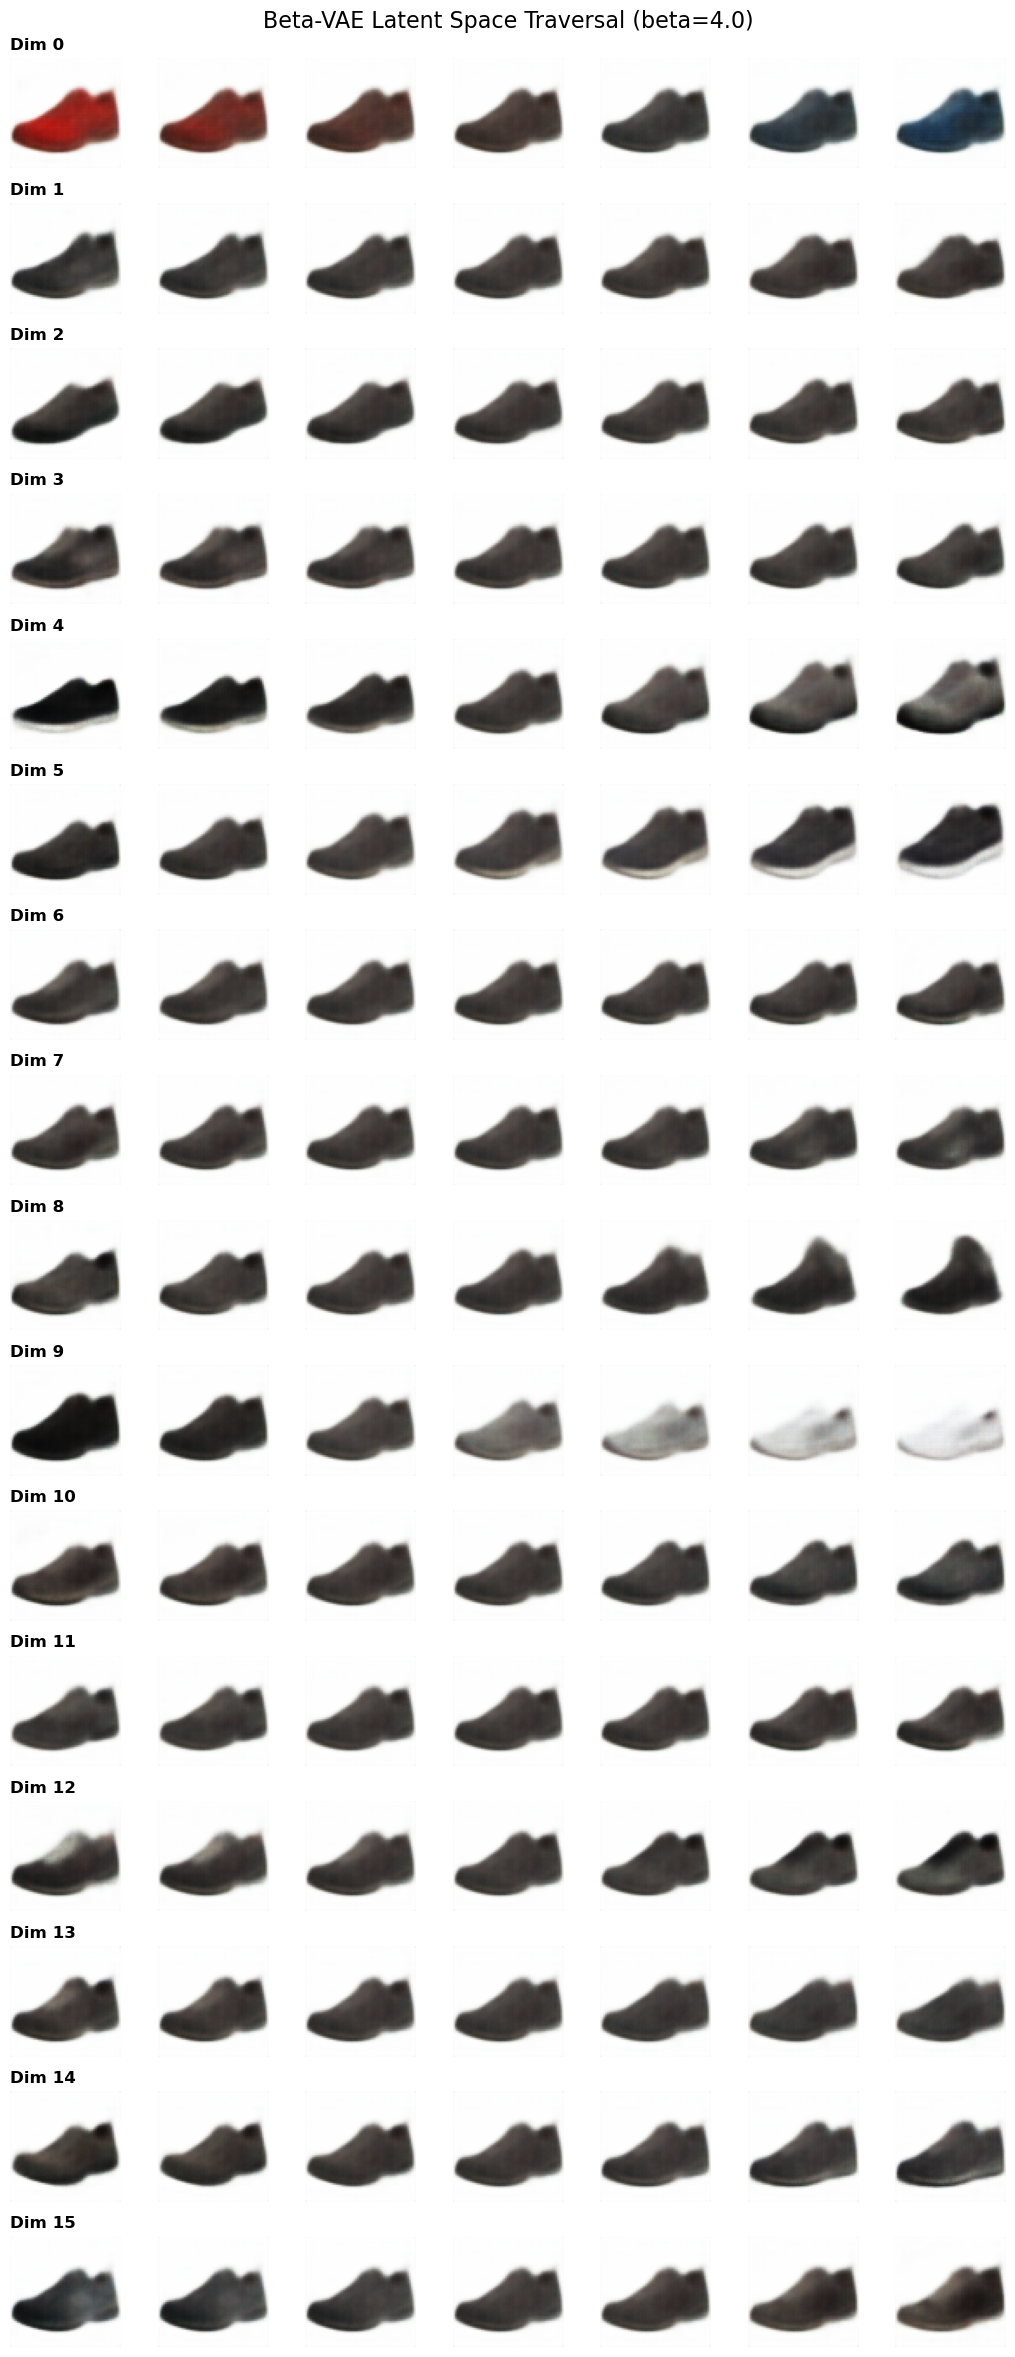

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_latent_traversal(model, device, dataloader, latent_dim=16, steps=7):
    model.eval() # 切换到评估模式，关闭 BatchNorm 的随机性
    
    # 1. 随机抓取一张真实的鞋子图片作为“基底”
    dataiter = iter(dataloader)
    real_batch, _ = next(dataiter)
    base_img = real_batch[0:1].to(device) # 只取第一张图片, Shape: [1, 3, 64, 64]
    
    # 2. 将基底图片输入编码器，获取它的隐空间坐标 (均值 mu)
    with torch.no_grad():
        _, mu, _ = model(base_img)
        base_z = mu.clone()
    
    print(f"🎨 正在生成特征解耦矩阵，这可能需要几秒钟...")
    
    # 准备画布: latent_dim 行 (16维度), steps 列 (从左到右的变化)
    fig, axes = plt.subplots(latent_dim, steps, figsize=(steps * 1.5, latent_dim * 1.5))
    
    # 设定滑动条的范围：从 -3 到 +3 (覆盖标准正态分布 99.7% 的区域)
    traversal_range = torch.linspace(-3.0, 3.0, steps=steps).to(device)
    
    with torch.no_grad():
        for dim in range(latent_dim):
            for i, val in enumerate(traversal_range):
                # 复制基准坐标
                z_traverse = base_z.clone()
                # 🌟 核心操作：固定其他 15 个维度不变，只强行修改当前维度的值 🌟
                z_traverse[0, dim] = val
                
                # 手动通过解码器生成图片
                z_decoded = model.fc_decode(z_traverse)
                z_reshaped = z_decoded.view(-1, 256, 4, 4)
                generated_img = model.decoder(z_reshaped)
                
                # 将 Tensor 转换为可显示的 Numpy 数组
                img_np = generated_img.squeeze().cpu().numpy()
                img_np = np.transpose(img_np, (1, 2, 0)) # [C, H, W] -> [H, W, C]
                
                # 画图
                ax = axes[dim, i]
                ax.imshow(img_np)
                ax.axis('off')
                
                if i == 0:
                    ax.set_title(f"Dim {dim}", loc='left', fontsize=12, fontweight='bold')

    plt.suptitle("Beta-VAE Latent Space Traversal (beta=4.0)", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.96)
    plt.show()

# 运行可视化函数
plot_latent_traversal(model, device, dataloader)

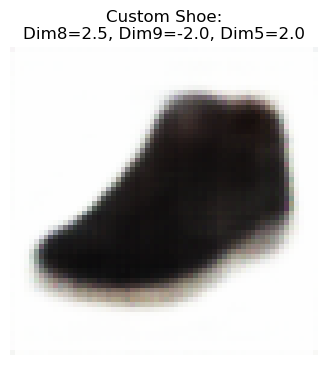

In [7]:
import torch
import matplotlib.pyplot as plt

def generate_custom_shoe(model, device, dim_settings):
    """
    dim_settings: 一个字典，键是维度索引，值是你想要的滑动条数值 (建议在 -3.0 到 3.0 之间)
    """
    model.eval()
    # 1. 初始化一个全为 0 的纯净隐变量 (代表最基础、平均的鞋子)
    z = torch.zeros(1, 16).to(device)
    
    # 2. 根据你破译的密码，拨动特定的开关
    for dim, value in dim_settings.items():
        z[0, dim] = value
        
    # 3. 解码生成
    with torch.no_grad():
        z_decoded = model.fc_decode(z)
        z_reshaped = z_decoded.view(-1, 256, 4, 4)
        generated_img = model.decoder(z_reshaped)
        
    # 4. 显示图片
    img_np = generated_img.squeeze().cpu().numpy()
    img_np = np.transpose(img_np, (1, 2, 0))
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img_np)
    plt.axis('off')
    
    # 动态生成标题
    title = "Custom Shoe:\n" + ", ".join([f"Dim{k}={v}" for k,v in dim_settings.items()])
    plt.title(title)
    plt.show()

# ==========================================
# 🎮 玩转你的模型 🎮
# ==========================================
# 假设你想生成一双：高帮 (Dim 8 = 2.5) + 白色主体 (Dim 9 = -2.0) 的鞋子
# 注意：正负号的影响取决于你刚才观察滑动条时的方向，你可能需要自己试一下正负
my_design = {
    8: 2.5,   # 控制高帮
    9: -2.0,  # 控制变白
    5: 2.0    # 假设让鞋底变白
}

generate_custom_shoe(model, device, my_design)

🔥 开始进阶训练！(包含 KL Annealing 和 BCE Loss)
Epoch [1/30] | Beta: 0.00 | Avg Loss: 2789.8113
Epoch [5/30] | Beta: 0.80 | Avg Loss: 2764.3750
Epoch [10/30] | Beta: 1.80 | Avg Loss: 2783.5713
Epoch [15/30] | Beta: 2.00 | Avg Loss: 2781.0056
Epoch [20/30] | Beta: 2.00 | Avg Loss: 2777.2145
Epoch [25/30] | Beta: 2.00 | Avg Loss: 2772.1198
Epoch [30/30] | Beta: 2.00 | Avg Loss: 2766.7128
✅ 进阶训练完成！


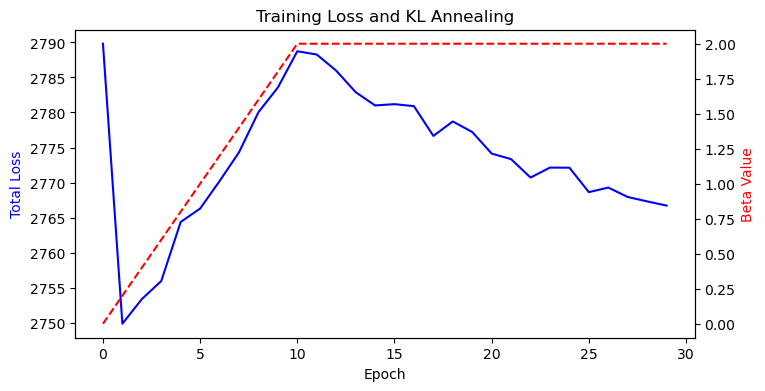

In [8]:
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# ==========================================
# 优化 1: 使用 BCE Loss 替代 MSE Loss
# ==========================================
def beta_vae_loss_improved(recon_x, x, mu, log_var, current_beta):
    # 使用 BCE 往往能得到比 MSE 更锐利的边缘
    # 注意：确保输入 x 和 recon_x 都在 [0, 1] 之间
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    
    # KL 散度保持不变
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    total_loss = recon_loss + current_beta * kl_loss
    return total_loss, recon_loss, kl_loss

# ==========================================
# 优化 2: KL Annealing (退火) 设置
# ==========================================
optimizer = optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 30  # 稍微增加几个 Epoch 让模型有时间适应
TARGET_BETA = 2.0  # 降低最终的惩罚力度，保全画质
ANNEAL_EPOCHS = 10 # 在前 10 个 Epoch 内慢慢增加 Beta

print("🔥 开始进阶训练！(包含 KL Annealing 和 BCE Loss)")

train_loss_history = []
beta_history = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    
    # 计算当前的 Beta 值 (线性增长直到达到 TARGET_BETA)
    if epoch < ANNEAL_EPOCHS:
        current_beta = TARGET_BETA * (epoch / ANNEAL_EPOCHS)
    else:
        current_beta = TARGET_BETA
        
    beta_history.append(current_beta)
    
    for batch_idx, (data, _) in enumerate(dataloader):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, log_var = model(data)
        
        # 传入动态计算的 current_beta
        loss, bce, kld = beta_vae_loss_improved(recon_batch, data, mu, log_var, current_beta)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    avg_loss = train_loss / len(dataloader.dataset)
    train_loss_history.append(avg_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Beta: {current_beta:.2f} | Avg Loss: {avg_loss:.4f}")

print("✅ 进阶训练完成！")

# 画图看看 Loss 和 Beta 的变化
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(train_loss_history, 'b-')
ax2.plot(beta_history, 'r--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Total Loss', color='b')
ax2.set_ylabel('Beta Value', color='r')
plt.title('Training Loss and KL Annealing')
plt.show()

🎨 正在生成【进阶版】特征解耦矩阵...


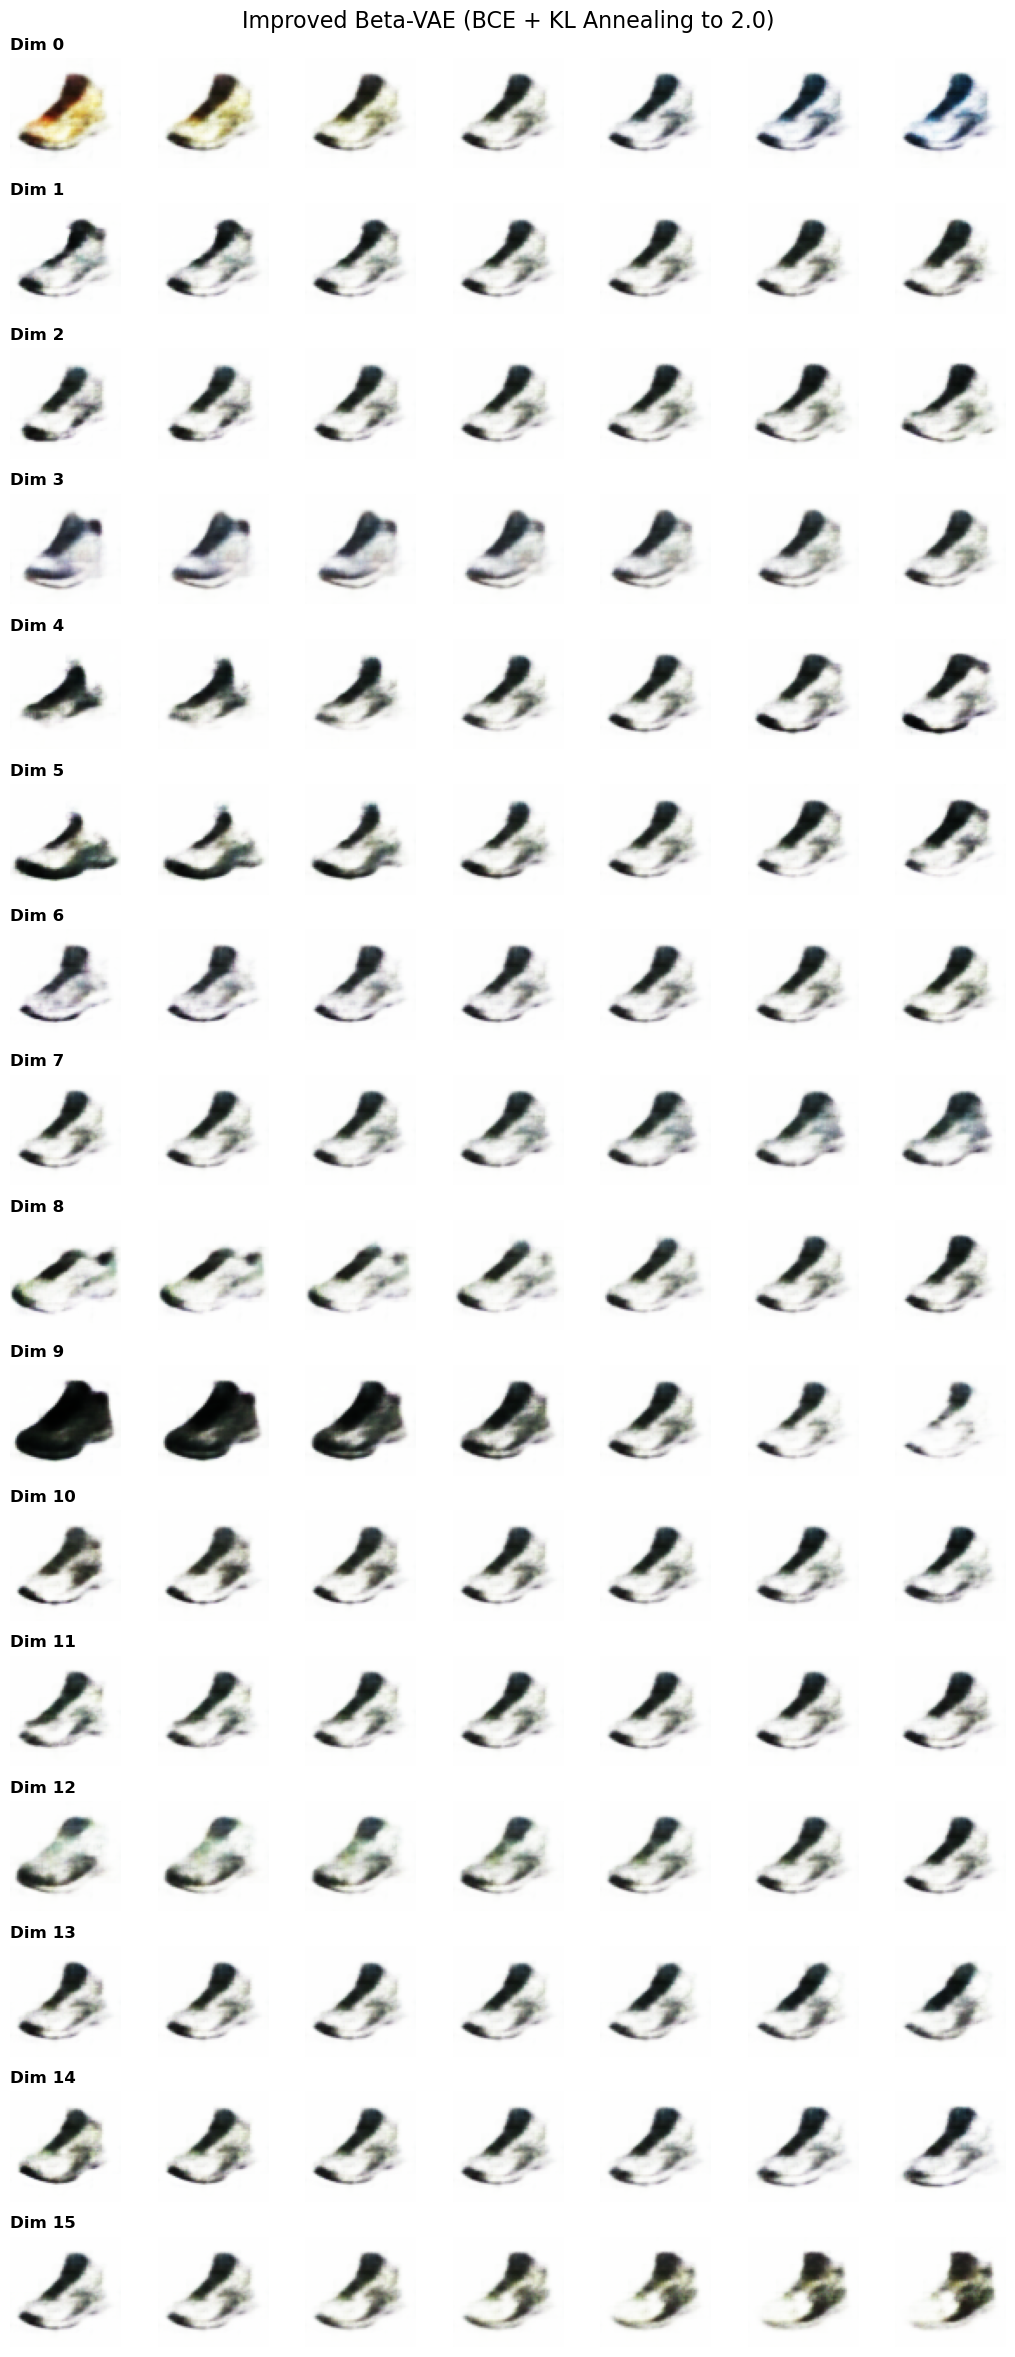

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ==========================================
# 1. 进阶版：隐空间遍历矩阵 (Latent Traversal)
# ==========================================
def plot_latent_traversal_improved(model, device, dataloader, latent_dim=16, steps=7):
    model.eval() 
    
    # 抓取一张真实的鞋子图片作为“基底”
    dataiter = iter(dataloader)
    real_batch, _ = next(dataiter)
    base_img = real_batch[0:1].to(device) 
    
    with torch.no_grad():
        _, mu, _ = model(base_img)
        base_z = mu.clone()
    
    print(f"🎨 正在生成【进阶版】特征解耦矩阵...")
    fig, axes = plt.subplots(latent_dim, steps, figsize=(steps * 1.5, latent_dim * 1.5))
    traversal_range = torch.linspace(-3.0, 3.0, steps=steps).to(device)
    
    with torch.no_grad():
        for dim in range(latent_dim):
            for i, val in enumerate(traversal_range):
                z_traverse = base_z.clone()
                z_traverse[0, dim] = val
                
                z_decoded = model.fc_decode(z_traverse)
                z_reshaped = z_decoded.view(-1, 256, 4, 4)
                generated_img = model.decoder(z_reshaped)
                
                img_np = generated_img.squeeze().cpu().numpy()
                img_np = np.transpose(img_np, (1, 2, 0))
                
                ax = axes[dim, i]
                ax.imshow(img_np)
                ax.axis('off')
                
                if i == 0:
                    ax.set_title(f"Dim {dim}", loc='left', fontsize=12, fontweight='bold')

    plt.suptitle("Improved Beta-VAE (BCE + KL Annealing to 2.0)", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.96)
    plt.show()


# ==========================================
# 2. 进阶版：生成定制鞋子 (Custom Shoe)
# ==========================================
def generate_custom_shoe_improved(model, device, dim_settings):
    model.eval()
    z = torch.zeros(1, 16).to(device)
    
    for dim, value in dim_settings.items():
        z[0, dim] = value
        
    with torch.no_grad():
        z_decoded = model.fc_decode(z)
        z_reshaped = z_decoded.view(-1, 256, 4, 4)
        generated_img = model.decoder(z_reshaped)
        
    img_np = generated_img.squeeze().cpu().numpy()
    img_np = np.transpose(img_np, (1, 2, 0))
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img_np)
    plt.axis('off')
    
    title = "Improved Custom Shoe:\n" + ", ".join([f"Dim{k}={v}" for k,v in dim_settings.items()])
    plt.title(title)
    plt.show()

# ==========================================
# 🚀 立即运行检阅效果
# ==========================================
# 1. 先跑矩阵图，看看维度控制有没有变化（因为重新训练后，每个维度负责的特征可能会洗牌打乱）
plot_latent_traversal_improved(model, device, dataloader)

正在生成你的专属定制款球鞋...


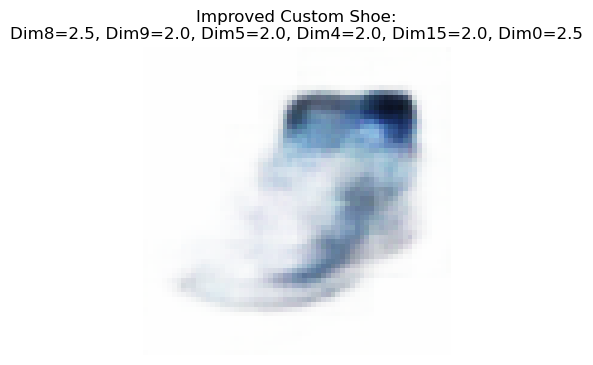

In [10]:
# ==========================================
# 🎨 基于你的独家“维度密码”进行定制生成 🎨
# ==========================================

# 设定你的球鞋参数 (数值一般在 -3.0 到 3.0 之间)
# 注意：如果生成效果与预期相反（比如变黑了而不是变白），只需要把正数改成负数即可！
my_custom_design = {
    8: 2.5,   # 【款式】强烈的高帮篮球鞋特征
    9: 2.0,   # 【鞋身】让鞋子主体变白
    5: 2.0,   # 【鞋底】让鞋底变白
    4: 2.0,   # 【细节】让底部的黑胶变得明显且清晰
    15: 2.0,  # 【细节】加深侧面的图案纹理
    0: 2.5    # 【色调】让整体颜色偏向蓝色 (黄->白->蓝的末端)
}

print("正在生成你的专属定制款球鞋...")

# 调用我们上一步定义的进阶版生成函数
generate_custom_shoe_improved(model, device, my_custom_design)